# Building Deep Learning Model for Classifying COVID-19 X-Ray Images


## Installing Required Libraries

In [1]:
!pip install torch torchvision pillow scikit-learn tqdm seaborn matplotlib pandas numpy -q

## Importing Libraries


In [2]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from tqdm.notebook import tqdm
from collections import Counter
import pandas as pd
import seaborn as sns
import json
from datetime import datetime
from google.colab import userdata
current_dir = userdata.get('current_dir')
os.chdir(current_dir)

In [3]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

## Data Preparation & Exploration

### Data Paths

In [4]:
current_dir = os.getcwd()
data_dir = os.path.join(current_dir, 'data')
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')

### Exploring Dataset Structure

In [5]:
for dir in os.listdir(data_dir):
    print(f"{dir}: {len(os.listdir(os.path.join(data_dir, dir)))}")
    for subdir in os.listdir(os.path.join(data_dir, dir)):
        print(f"\t-{subdir}: {len(os.listdir(os.path.join(data_dir, dir, subdir)))}")

test: 2
	-NORMAL: 20
	-PNEUMONIA: 20
train: 2
	-NORMAL: 74
	-PNEUMONIA: 74


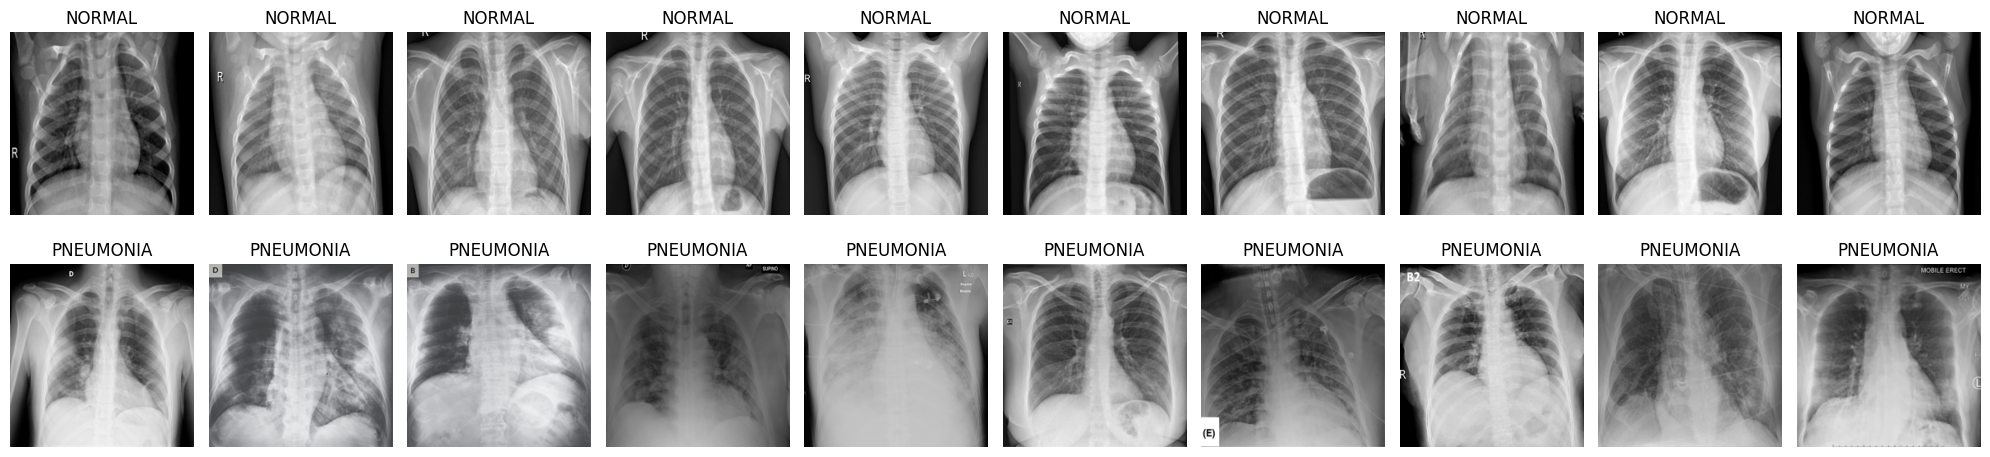

In [6]:
fig, ax = plt.subplots(2, 10, figsize=(20, 5))

for i, dir in enumerate(os.listdir(train_dir)):
    class_images = np.random.choice(os.listdir(os.path.join(train_dir, dir)), size=10, replace=False)

    for j, img_name in enumerate(class_images):
        img_path = os.path.join(train_dir, dir, img_name)
        img = Image.open(img_path).resize((224, 224))
        ax[i, j].imshow(img, cmap='gray')
        ax[i, j].axis('off')
        ax[i, j].set_title(dir)
plt.tight_layout()
plt.show()



## Data Preprocessing & Augmentation

### Custom Transform for Grayscale Conversion

In [7]:
class ConvertToGrayscale:
    def __call__(self, image):
        # If tensor, convert it back to PIL before grayscale
        if isinstance(image, torch.Tensor):
            image = transforms.ToPILImage()(image)
        if image.mode != 'L':
            image = image.convert('L')
        return image

### Compute Dataset Statistics Properly


In [8]:
def compute_mean_std(dataset, batch_size=32):
    """Compute mean and standard deviation from a dataset"""
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    mean = 0.0
    std = 0.0
    total_samples = 0

    print("Computing dataset statistics...")
    for images, _ in tqdm(loader, desc="Computing mean and std"):
        batch_samples = images.size(0)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_samples += batch_samples

    mean /= total_samples
    std /= total_samples

    return mean, std

### Create Proper Data Splits and Transforms

In [9]:
def prepare_data_splits(train_dir, val_split=0.2, batch_size=32):
    """
    Prepare train/validation splits with proper normalization
    without data leakage
    """
    # Step 1: Initial transform without normalization (for stats computation)
    simple_transform = transforms.Compose([
        ConvertToGrayscale(),
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    # Load full dataset
    full_dataset = datasets.ImageFolder(root=train_dir, transform=simple_transform)
    print(f"Full dataset: {len(full_dataset)} images")
    print(f"Classes: {full_dataset.classes}")
    print(f"Class to index: {full_dataset.class_to_idx}")

    # Step 2: Split into train and validation
    train_size = int((1 - val_split) * len(full_dataset))
    val_size = len(full_dataset) - train_size

    print(f"\nSplitting dataset:")
    print(f"Training samples: {train_size}")
    print(f"Validation samples: {val_size}")

    train_subset, val_subset = random_split(
        full_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    # Step 3: Compute mean and std  from training data
    train_mean, train_std = compute_mean_std(train_subset, batch_size)
    print(f"\nDataset Statistics (from training set ):")
    print(f"Mean: {train_mean.item():.4f}")
    print(f"Std:  {train_std.item():.4f}")

    # Step 4: Define transforms with augmentation for training
    train_transform = transforms.Compose([
        ConvertToGrayscale(),
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=(-10, 10)),
        transforms.RandomAffine(
            degrees=(-8, 8),
            translate=(0.05, 0.05),
            scale=(0.95, 1.05)
        ),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[train_mean.item()], std=[train_std.item()])
    ])

    # Transform for validation (no augmentation)
    val_transform = transforms.Compose([
        ConvertToGrayscale(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[train_mean.item()], std=[train_std.item()])
    ])

    # Step 5: Apply transforms to subsets
    class TransformDataset(datasets.ImageFolder):
        def __init__(self, subset, transform=None):
            self.subset = subset
            self.transform = transform

        def __getitem__(self, index):
            x, y = self.subset[index]
            if self.transform:
                x = self.transform(x)
            return x, y

        def __len__(self):
            return len(self.subset)

    train_dataset = TransformDataset(train_subset, train_transform)
    val_dataset = TransformDataset(val_subset, val_transform)

    return train_dataset, val_dataset, full_dataset.classes, train_mean.item(), train_std.item()

In [10]:
# Prepare the data
train_dataset, val_dataset, class_names, train_mean, train_std = prepare_data_splits(train_dir)
print(f"\nFinal datasets:")
print(f"Training: {len(train_dataset)} images")
print(f"Validation: {len(val_dataset)} images")
print(f"Classes: {class_names}")

Full dataset: 148 images
Classes: ['NORMAL', 'PNEUMONIA']
Class to index: {'NORMAL': 0, 'PNEUMONIA': 1}

Splitting dataset:
Training samples: 118
Validation samples: 30
Computing dataset statistics...


Computing mean and std:   0%|          | 0/4 [00:00<?, ?it/s]


Dataset Statistics (from training set ):
Mean: 0.5170
Std:  0.2072

Final datasets:
Training: 118 images
Validation: 30 images
Classes: ['NORMAL', 'PNEUMONIA']


### Analyze Class Distribution

In [11]:
def analyze_class_distribution(dataset, dataset_name, class_names):
    """Analyze and plot class distribution"""
    labels = []
    for i in range(len(dataset)):
        _, label = dataset[i]
        labels.append(label)

    label_counts = Counter(labels)

    # Create mapping from index to class name
    index_to_class = {i: class_name for i, class_name in enumerate(class_names)}

    # Convert to class names
    class_distribution = {index_to_class[idx]: count for idx, count in label_counts.items()}

    # Plot
    plt.figure(figsize=(10, 6))
    bars = plt.bar(class_distribution.keys(), class_distribution.values(), color=['skyblue', 'lightcoral'])
    plt.title(f'Class Distribution - {dataset_name}')
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    return class_distribution

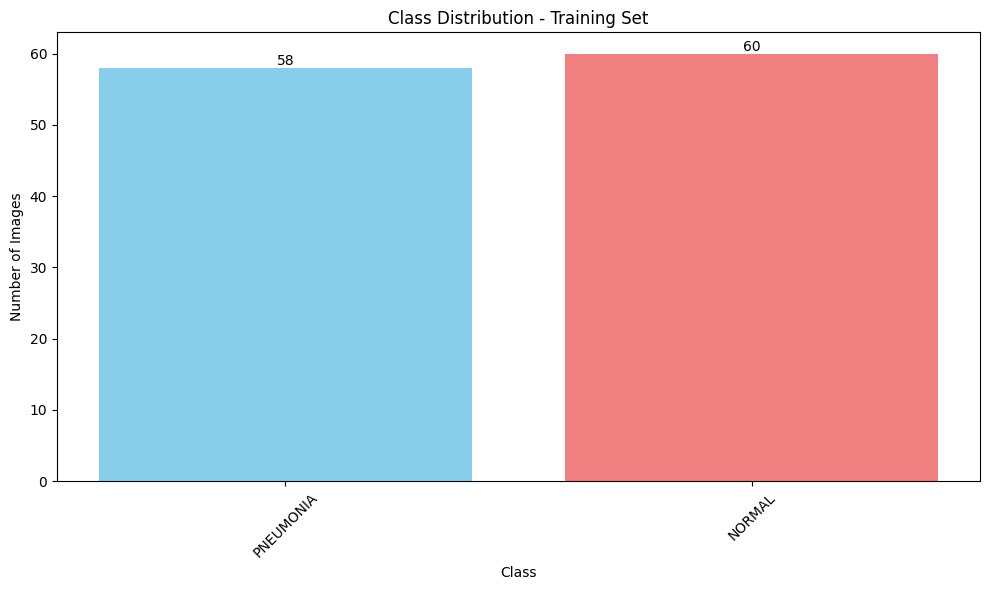

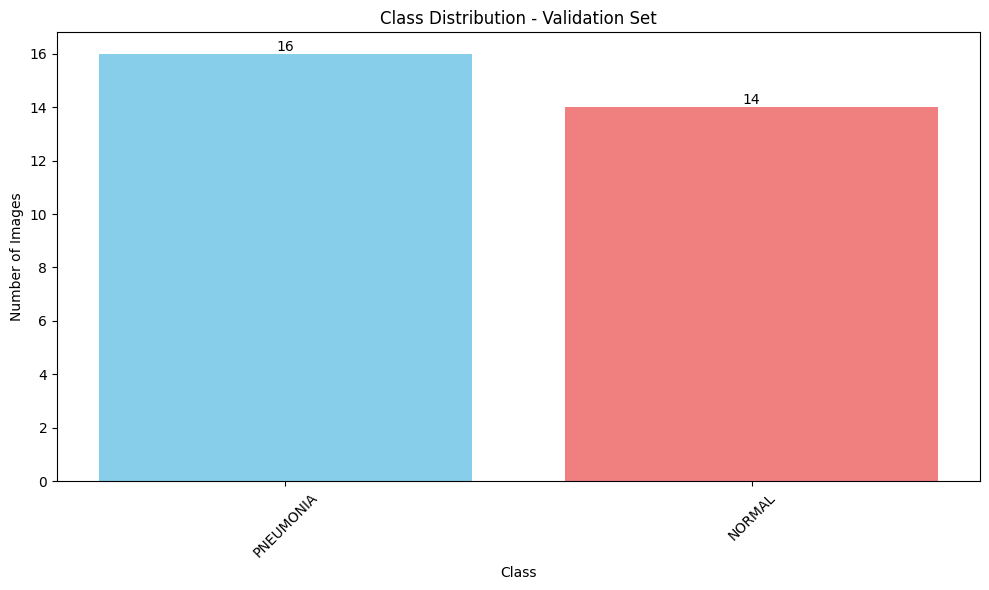

In [12]:
train_dist = analyze_class_distribution(train_dataset, "Training Set", class_names)
val_dist = analyze_class_distribution(val_dataset, "Validation Set", class_names)


### Create DataLoaders

In [13]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    generator=torch.Generator().manual_seed(42)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,  # Important: don't shuffle validation
    num_workers=2
)

In [14]:
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 4
Val batches: 1


In [15]:
# Test one batch
sample_batch = next(iter(train_loader))
images, labels = sample_batch
print(f"Batch image shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")

Batch image shape: torch.Size([32, 1, 224, 224])
Batch labels shape: torch.Size([32])


## Model Building


### Define COVID-19 CNN Model


In [16]:
class COVIDCNN(nn.Module):
    """CNN model for COVID-19 X-ray classification"""

    def __init__(self, num_classes=2, dropout_rate=0.5):
        super(COVIDCNN, self).__init__()

        # Feature extraction layers
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Classifier with dropout
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),  # After flattening, before first FC
            nn.Linear(256 * 14 * 14, 512),  # Adjusted based on input size 224x224
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout_rate * 0.8),  # Between FC layers
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout_rate * 0.6),  # Lower dropout near output
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = nn.Flatten()(x)
        x = self.classifier(x)
        return x

### Model Initialization and Setup

In [17]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [18]:
# Model initialization
model = COVIDCNN(num_classes=len(class_names), dropout_rate=0.5)
model.to(device)

print("Model Architecture:")
print(model)

Model Architecture:
COVIDCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-0

In [19]:
# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Total parameters: 26,212,802
Trainable parameters: 26,212,802


### Loss Function with Class Weights

In [20]:
def calculate_class_weights(dataset, num_classes):
    """Calculate class weights for imbalanced datasets"""
    labels = []
    for i in range(len(dataset)):
        _, label = dataset[i]
        labels.append(label)

    class_counts = Counter(labels)
    total_samples = len(labels)

    # Calculate weights (inverse frequency)
    weights = []
    for class_idx in range(num_classes):
        count = class_counts.get(class_idx, 1)  # Avoid division by zero
        weight = total_samples / (num_classes * count)
        weights.append(weight)

    weights = torch.tensor(weights, dtype=torch.float32).to(device)
    print(f"Class counts: {class_counts}")
    print(f"Class weights: {weights}")

    return weights

In [21]:
# Calculate class weights for imbalanced data
class_weights = calculate_class_weights(train_dataset, len(class_names))

Class counts: Counter({0: 60, 1: 58})
Class weights: tensor([0.9833, 1.0172], device='cuda:0')


In [22]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                       factor=0.5, patience=3)

print(f"Loss function: CrossEntropyLoss with class weights")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Scheduler: ReduceLROnPlateau")

Loss function: CrossEntropyLoss with class weights
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau


## Training Utilities

### Training and Evaluation Functions

In [23]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    train_bar = tqdm(train_loader, desc="Training")

    for batch_idx, (images, labels) in enumerate(train_bar):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

        # Update progress bar
        train_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100.*correct_predictions/total_samples:.2f}%'
        })

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct_predictions / total_samples

    return epoch_loss, epoch_acc

In [24]:
def validate_epoch(model, val_loader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc="Validation")

        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            val_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct_predictions/total_samples:.2f}%'
            })

    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct_predictions / total_samples

    return epoch_loss, epoch_acc, all_predictions, all_labels

In [25]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs=20):
    """Complete training loop"""
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    best_val_acc = 0.0
    best_model_state = None

    print("Starting training...")
    print(f"{'Epoch':^6} | {'Train Loss':^10} | {'Train Acc':^9} | {'Val Loss':^10} | {'Val Acc':^8} | {'LR':^8}")
    print("-" * 70)

    for epoch in range(epochs):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

        # Validate
        val_loss, val_acc, val_preds, val_labels = validate_epoch(model, val_loader, criterion, device)

        # Update learning rate
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        # Store metrics
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        # Print progress
        print(f"{epoch+1:^6} | {train_loss:^10.4f} | {train_acc:^8.2f}% | {val_loss:^10.4f} | {val_acc:^7.2f}% | {current_lr:^8.6f}")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            torch.save(best_model_state, 'best_covid_model.pth')
            print(f"  ↳ New best model saved! Val Acc: {val_acc:.2f}%")

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nLoaded best model with validation accuracy: {best_val_acc:.2f}%")

    return {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies,
        'best_val_acc': best_val_acc
    }


## Model Training

In [26]:
epochs = 25
print(f"Training for {epochs} epochs...")

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=epochs
)

Training for 25 epochs...
Starting training...
Epoch  | Train Loss | Train Acc |  Val Loss  | Val Acc  |    LR   
----------------------------------------------------------------------


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

  1    |   0.6024   |  66.10  % |   0.6027   |  53.33 % | 0.001000
  ↳ New best model saved! Val Acc: 53.33%


Training:   0%|          | 0/4 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

  24   |   0.0464   |  99.15  % |   0.0232   | 100.00 % | 0.000125


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

  25   |   0.0671   |  98.31  % |   0.0233   | 100.00 % | 0.000063

Loaded best model with validation accuracy: 100.00%


### Plot Training History

In [27]:
def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot losses
    ax1.plot(history['train_losses'], label='Training Loss', linewidth=2)
    ax1.plot(history['val_losses'], label='Validation Loss', linewidth=2)
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracies
    ax2.plot(history['train_accuracies'], label='Training Accuracy', linewidth=2)
    ax2.plot(history['val_accuracies'], label='Validation Accuracy', linewidth=2)
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


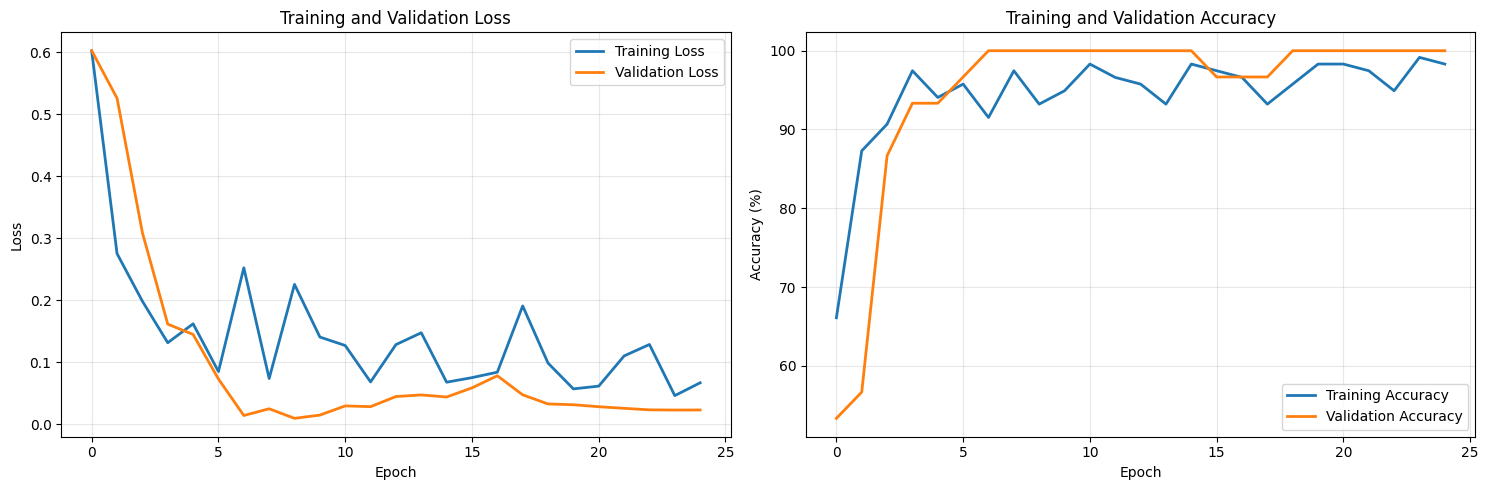

In [28]:
plot_training_history(history)

## Model Evaluation

### Comprehensive Evaluation Function


In [30]:
def comprehensive_evaluation(model, data_loader, class_names, device):
    """Comprehensive model evaluation"""
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []

    print("Running evaluation...")
    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Evaluating"):
            images = images.to(device)
            outputs = model(images)
            probabilities = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    # Convert to numpy arrays
    y_true = np.array(all_labels)
    y_pred = np.array(all_predictions)
    y_proba = np.array(all_probabilities)

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

    return y_true, y_pred, y_proba, accuracy, cm, report

In [31]:
def plot_confusion_matrix(cm, class_names, title='Confusion Matrix'):
    """Plot confusion matrix"""
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

In [32]:
def print_detailed_report(report, accuracy, dataset_name):
    """Print detailed classification report"""
    print("=" * 70)
    print(f"{dataset_name.upper()} RESULTS")
    print("=" * 70)
    print(f"Overall Accuracy: {accuracy:.4f}")
    print("\nDetailed Classification Report:")
    print("-" * 70)

    # Create a DataFrame for better display
    report_df = pd.DataFrame(report).transpose()
    print(report_df.round(4))

    return report_df

### Validation Set Evaluation

In [33]:
# Evaluate on validation set
print("VALIDATION SET EVALUATION")
print("=" * 50)

val_true, val_pred, val_proba, val_accuracy, val_cm, val_report = comprehensive_evaluation(
    model, val_loader, class_names, device
)


VALIDATION SET EVALUATION
Running evaluation...


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

In [34]:
val_report_df = print_detailed_report(val_report, val_accuracy, "Validation Set")
val_report_df

VALIDATION SET RESULTS
Overall Accuracy: 1.0000

Detailed Classification Report:
----------------------------------------------------------------------
              precision  recall  f1-score  support
NORMAL              1.0     1.0       1.0     14.0
PNEUMONIA           1.0     1.0       1.0     16.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0     30.0
weighted avg        1.0     1.0       1.0     30.0


,precision,recall,f1-score,support
NORMAL,1.0,1.0,1.0,14.0
PNEUMONIA,1.0,1.0,1.0,16.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,30.0
weighted avg,1.0,1.0,1.0,30.0


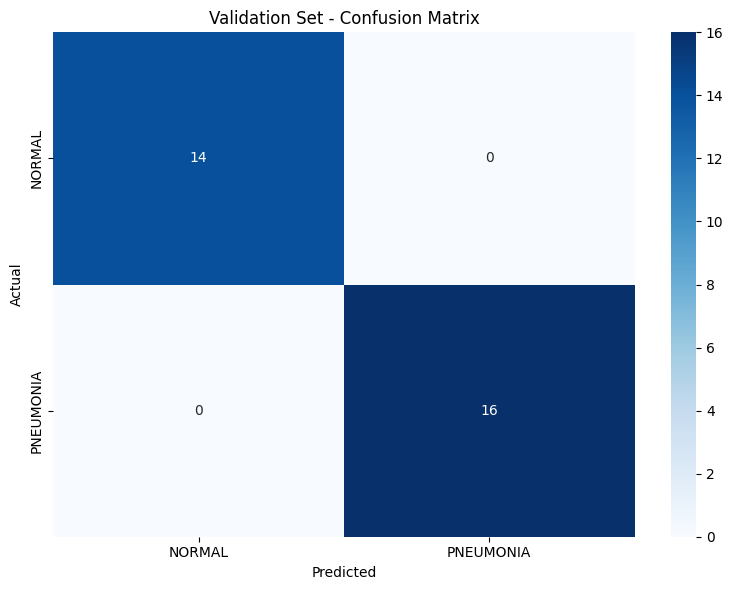

In [35]:
plot_confusion_matrix(val_cm, class_names, 'Validation Set - Confusion Matrix')

### Test Set Evaluation

In [36]:
# Prepare test set
test_transform = transforms.Compose([
    ConvertToGrayscale(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[train_mean], std=[train_std])
])

test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Test dataset: {len(test_dataset)} images")
print(f"Test classes: {test_dataset.classes}")


Test dataset: 40 images
Test classes: ['NORMAL', 'PNEUMONIA']


In [37]:
# Evaluate on test set
print("\nTEST SET EVALUATION")
print("=" * 50)

test_true, test_pred, test_proba, test_accuracy, test_cm, test_report = comprehensive_evaluation(
    model, test_loader, class_names, device
)
print_detailed_report(test_report, test_accuracy, "Test Set")



TEST SET EVALUATION
Running evaluation...


Evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

TEST SET RESULTS
Overall Accuracy: 1.0000

Detailed Classification Report:
----------------------------------------------------------------------
              precision  recall  f1-score  support
NORMAL              1.0     1.0       1.0     20.0
PNEUMONIA           1.0     1.0       1.0     20.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0     40.0
weighted avg        1.0     1.0       1.0     40.0


,precision,recall,f1-score,support
NORMAL,1.0,1.0,1.0,20.0
PNEUMONIA,1.0,1.0,1.0,20.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,40.0
weighted avg,1.0,1.0,1.0,40.0


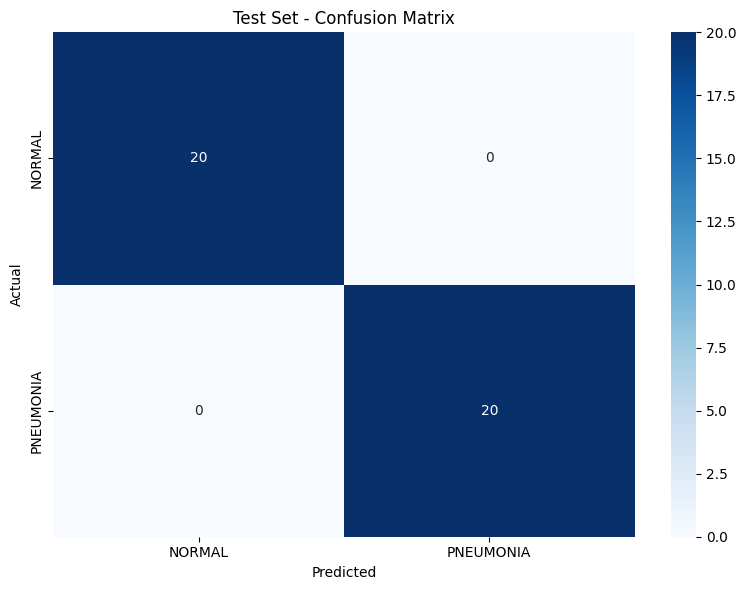

In [38]:
plot_confusion_matrix(test_cm, class_names, 'Test Set - Confusion Matrix')


### Per-Class Analysis

In [39]:
def plot_per_class_metrics(report_dict, class_names, dataset_name):
    """Plot per-class metrics"""
    metrics = ['precision', 'recall', 'f1-score']
    colors = ['skyblue', 'lightcoral', 'lightgreen']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{dataset_name} - Per-Class Metrics', fontsize=16, y=1.05)

    for idx, metric in enumerate(metrics):
        values = [report_dict[class_name][metric] for class_name in class_names]
        bars = axes[idx].bar(class_names, values, color=colors[idx], alpha=0.7)
        axes[idx].set_title(f'{metric.title()}')
        axes[idx].set_ylim(0, 1.1)
        axes[idx].tick_params(axis='x', rotation=45)

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                          f'{height:.3f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

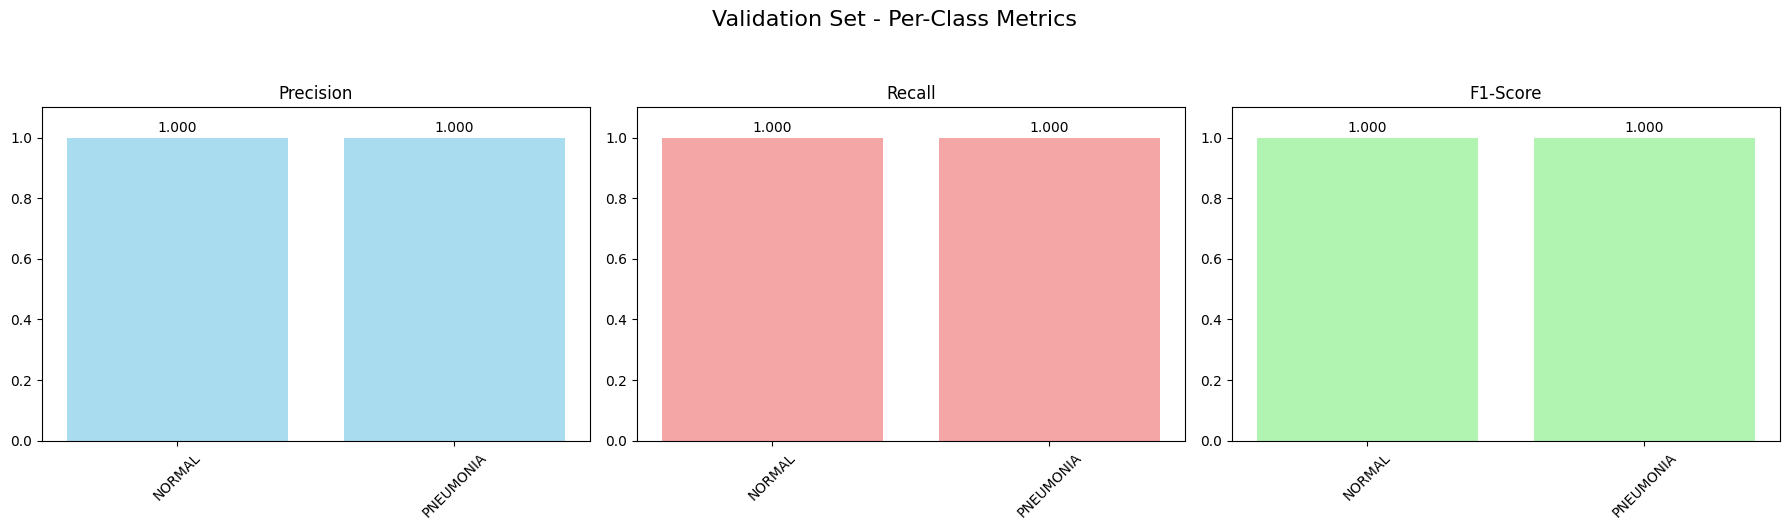

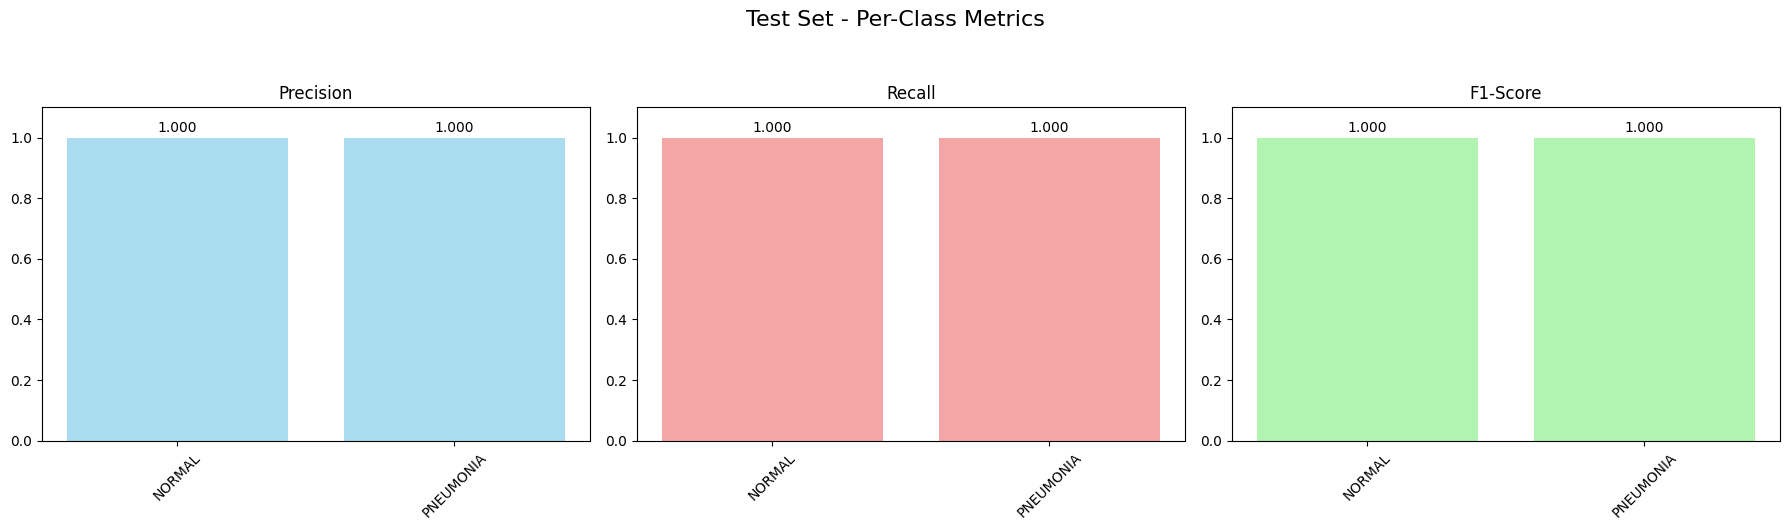

In [41]:
plot_per_class_metrics(val_report, class_names, "Validation Set")
plot_per_class_metrics(test_report, class_names, "Test Set")


### ROC Curve (for binary classification)

In [42]:
def plot_roc_curve(y_true, y_proba, class_names, dataset_name):
    """Plot ROC curve for binary classification"""
    if len(class_names) == 2:
        from sklearn.metrics import roc_curve, auc

        fpr, tpr, _ = roc_curve(y_true, y_proba[:, 1])
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2,
                label=f'ROC curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{dataset_name} - ROC Curve')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.show()

        print(f"AUC-ROC Score: {roc_auc:.4f}")
        return roc_auc
    else:
        print("ROC curve is typically for binary classification.")
        return None

VALIDATION SET ROC CURVE


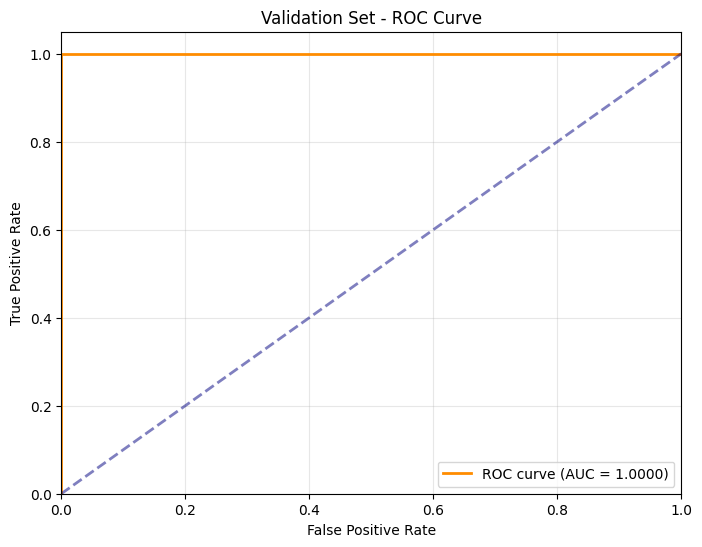

AUC-ROC Score: 1.0000

TEST SET ROC CURVE


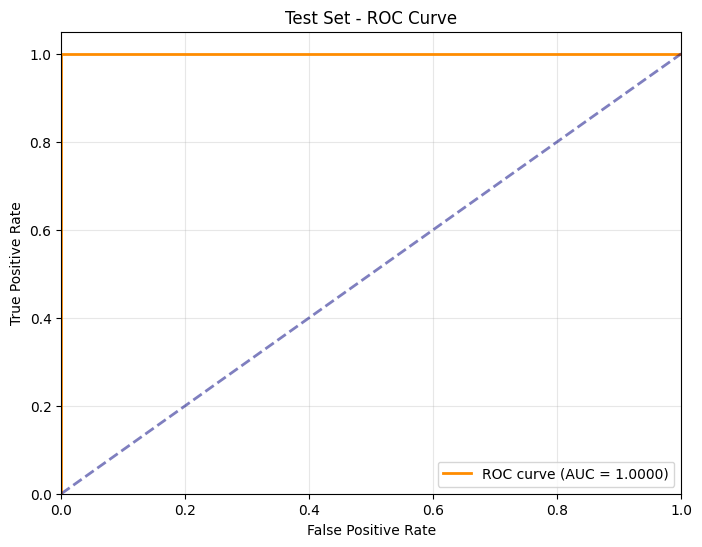

AUC-ROC Score: 1.0000


In [43]:
if len(class_names) == 2:
    print("VALIDATION SET ROC CURVE")
    val_auc = plot_roc_curve(val_true, val_proba, class_names, "Validation Set")

    print("\nTEST SET ROC CURVE")
    test_auc = plot_roc_curve(test_true, test_proba, class_names, "Test Set")


## Model Interpretation


### Visualize Predictions


In [44]:
def visualize_predictions(model, data_loader, class_names, device, num_samples=12):
    """Visualize model predictions on sample images"""
    model.eval()

    # Get a batch of data
    images, labels = next(iter(data_loader))
    images = images.to(device)

    # Get predictions
    with torch.no_grad():
        outputs = model(images)
        probabilities = F.softmax(outputs, dim=1)
        _, predictions = torch.max(outputs, 1)

    # Convert to CPU for plotting
    images = images.cpu()
    labels = labels.cpu()
    predictions = predictions.cpu()
    probabilities = probabilities.cpu()

    # Plot
    num_samples = min(num_samples, len(images))
    fig, axes = plt.subplots(3, 4, figsize=(15, 12))
    axes = axes.ravel()

    for i in range(num_samples):
        # Denormalize image
        img = images[i].squeeze()
        img = img * train_std + train_mean  # Denormalize
        img = np.clip(img, 0, 1)

        # Plot
        axes[i].imshow(img, cmap='gray')

        # Set title with color coding
        true_label = class_names[labels[i]]
        pred_label = class_names[predictions[i]]
        confidence = probabilities[i][predictions[i]].item()

        color = 'green' if true_label == pred_label else 'red'
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.3f}',
                         color=color, fontsize=10)
        axes[i].axis('off')

    # Hide empty subplots
    for i in range(num_samples, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

Sample Predictions on Validation Set:


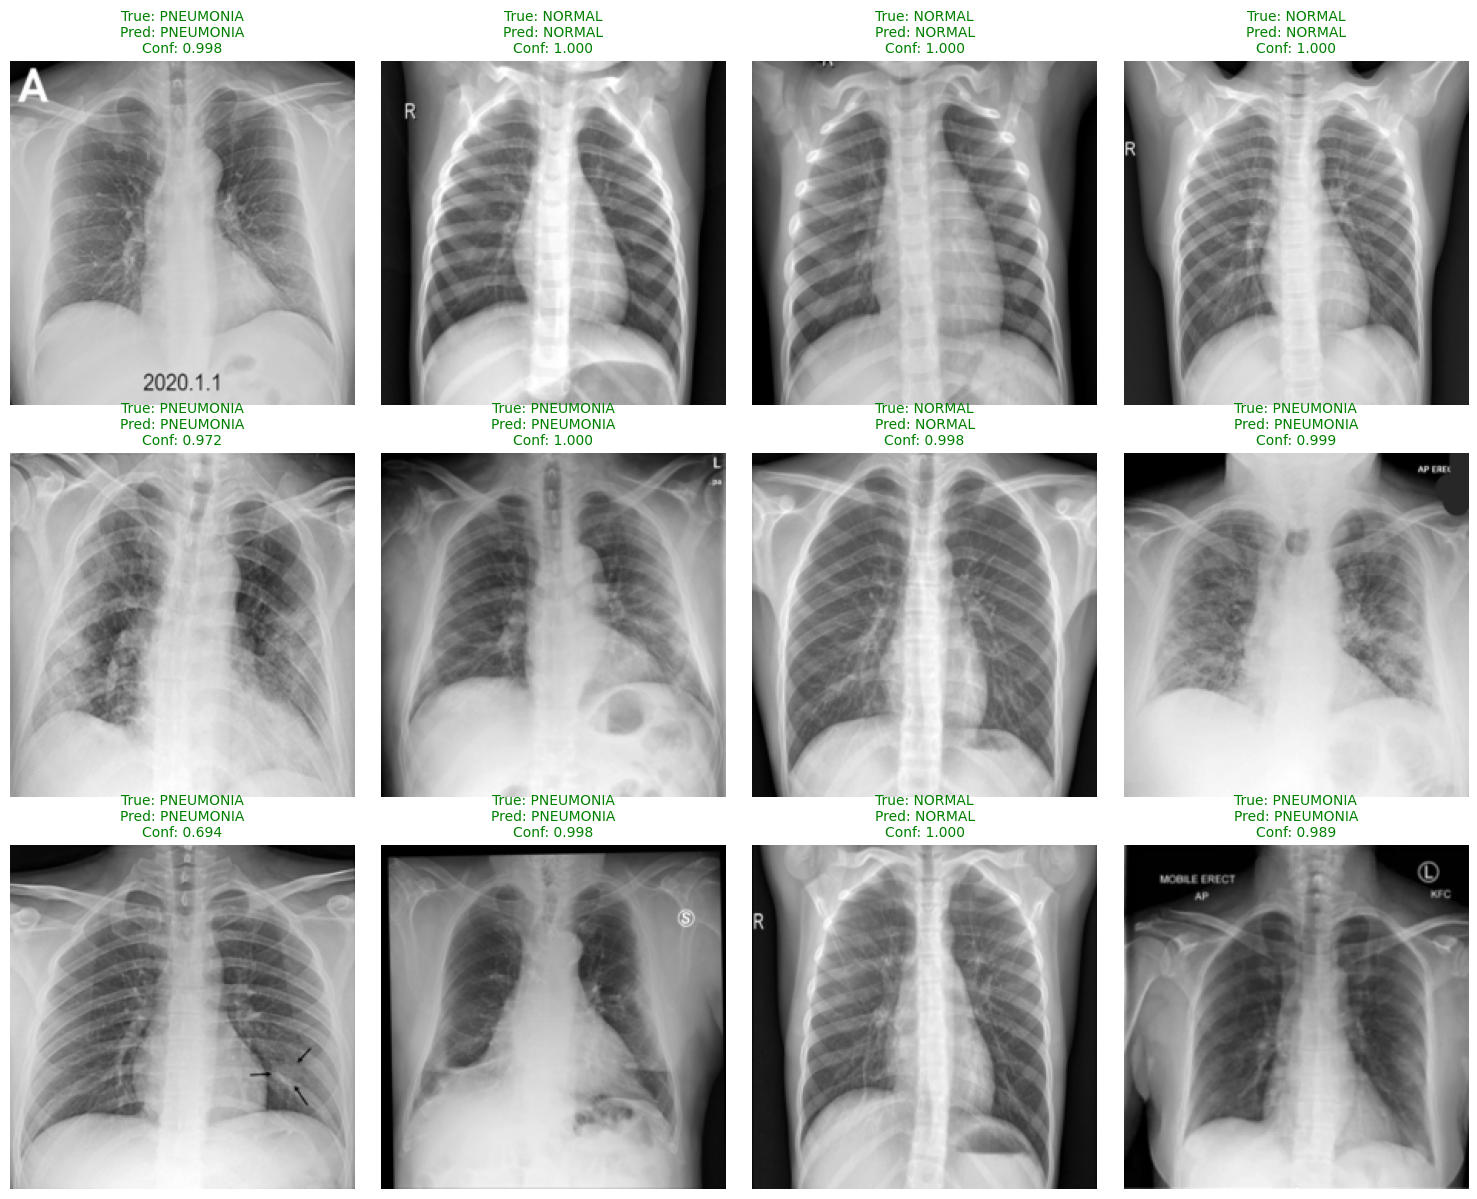

In [46]:
print("Sample Predictions on Validation Set:")
visualize_predictions(model, val_loader, class_names, device)

### Save Results

In [47]:
def save_results(history, val_report, test_report, class_names, filename='covid19_results.json'):
    """Save all results to a JSON file"""
    results = {
        'timestamp': datetime.now().isoformat(),
        'class_names': class_names,
        'training_history': {
            'train_losses': history['train_losses'],
            'train_accuracies': history['train_accuracies'],
            'val_losses': history['val_losses'],
            'val_accuracies': history['val_accuracies'],
            'best_val_accuracy': history['best_val_acc']
        },
        'validation_results': val_report,
        'test_results': test_report,
        'model_info': {
            'total_parameters': sum(p.numel() for p in model.parameters()),
            'trainable_parameters': sum(p.numel() for p in model.parameters() if p.requires_grad),
            'architecture': 'COVIDCNN'
        }
    }

    with open(filename, 'w') as f:
        json.dump(results, f, indent=2)

    print(f"Results saved to {filename}")


In [48]:
# Save all results
save_results(history, val_report, test_report, class_names, 'covid19_xray_results.json')

Results saved to covid19_xray_results.json


## Final Summary

In [49]:
print("FINAL TRAINING SUMMARY")
print("=" * 70)
print(f"Best Validation Accuracy: {history['best_val_acc']:.2f}%")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Number of Classes: {len(class_names)}")
print(f"Classes: {class_names}")

if len(class_names) == 2:
    print(f"Validation AUC: {val_auc:.4f}" if 'val_auc' in locals() else "")
    print(f"Test AUC: {test_auc:.4f}" if 'test_auc' in locals() else "")

print("\nKey Metrics:")
print("-" * 40)
for class_name in class_names:
    if class_name in test_report:
        precision = test_report[class_name]['precision']
        recall = test_report[class_name]['recall']
        f1 = test_report[class_name]['f1-score']
        print(f"{class_name:>15}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")

print("\n" + "=" * 70)
print("Training and Evaluation Complete!")

FINAL TRAINING SUMMARY
Best Validation Accuracy: 100.00%
Test Accuracy: 1.0000
Number of Classes: 2
Classes: ['NORMAL', 'PNEUMONIA']
Validation AUC: 1.0000
Test AUC: 1.0000

Key Metrics:
----------------------------------------
         NORMAL: Precision=1.000, Recall=1.000, F1=1.000
      PNEUMONIA: Precision=1.000, Recall=1.000, F1=1.000

Training and Evaluation Complete!
